In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Weinstock data
Weinstock = pd.read_excel("/g/stegle/schrod/code/TCell/Weinstock_S4.xlsx")
Weinstock = Weinstock[Weinstock['padj'] < 0.05]
Weinstock = Weinstock.rename(columns = {'log2FoldChange': 'LFC_Weinstock'})[['KO', 'gene_name', 'LFC_Weinstock']]

In [3]:
# Helper function to load DEG results
def load_deg_results(file_path, pval_threshold = None):
    df_list = []
    for file_name in os.listdir(file_path):
        if pval_threshold is not None:
            df_tmp = df_tmp[df_tmp["pvals_adj"] < pval_threshold]
        df_list.append(df_tmp)
    df1 = pd.concat(df_list)
    return df1

In [4]:
# Load all methods
# 1. SCEPTRE
sceptre = pd.read_csv('/g/steinmetz/project/otar_2063/promoter_screen/interpretation/diff_expr_analyses/process_trans_analysis/sceptre_pvalues/all_pairs.tsv.gz', sep = '\t')
sceptre = sceptre.rename(columns = {'grna_target': 'KO', 'gene_symbol': 'gene_name', 'log_2_fold_change': 'our_LFC', 'p_value_adj': 'our_adj_pval'})
sceptre = Weinstock.merge(sceptre[['KO', 'gene_name', 'our_LFC', 'our_adj_pval']])

# 2. Wilcoxon
wilcoxon = load_deg_results('/g/stegle/schrod/code/TCell/results_single_cell/Wilcoxon_single_cell_final')
wilcoxon = wilcoxon.rename(columns = {'group': 'KO', 'names': 'gene_name', 'scores': 'our_LFC', 'pvals_adj': 'our_adj_pval'})
wilcoxon = Weinstock.merge(wilcoxon[['KO', 'gene_name', 'our_LFC', 'our_adj_pval']])

# 3. Limma
limma = pd.read_csv('/g/steinmetz/project/otar_2063/promoter_screen/interpretation/DE/output/combined/DEG_single_cell_limma_ebayes_split_NT_removed_all_covariates_prefiltered_genes_gene_combined_2026-02-03.tsv.gz')
limma = limma.rename(columns = {'Perturbation': 'KO', 'Target': 'gene_name', 'logFC': 'our_LFC', 'adj.P.Val': 'our_adj_pval'})
limma = Weinstock.merge(limma[['KO', 'gene_name', 'our_LFC', 'our_adj_pval']])

# 4. Pseudobulk
bulk = load_deg_results('/g/stegle/schrod/code/TCell/results_pseudobulk/DEG_bulk_rerun')
bulk = bulk.rename(columns = {'group': 'KO', 'names': 'gene_name', 'scores': 'our_LFC', 'pvals_adj': 'our_adj_pval'})
bulk = Weinstock.merge(bulk[['KO', 'gene_name', 'our_LFC', 'our_adj_pval']])

# 5. DESeq2
DESeq = load_deg_results('/g/stegle/schrod/code/TCell/pseudobulk_deseq2_chunks50_min3bulks_ribosomal')
DESeq = DESeq.rename(columns = {'contrast': 'KO', 'variable': 'gene_name', 'log_fc': 'our_LFC', 'adj_p_value': 'our_adj_pval'})
DESeq = Weinstock.merge(DESeq[['KO', 'gene_name', 'our_LFC', 'our_adj_pval']])

In [5]:
# Calculate correlations across all genes
def calculate_correlations(df_list, name_list):
    corr_df = pd.DataFrame()
    for method_df, name in zip(df_list, name_list):
        corr_method = method_df.groupby("KO").apply(lambda g: g["LFC_Weinstock"].corr(g["our_LFC"])).rename(name)
        corr_df = pd.concat([corr_df, corr_method], axis = 1)
    corr_long = corr_df.reset_index(names = "KO").melt(id_vars = 'KO', var_name="method", value_name="correlation").dropna()
    
    # Filter for perturbations that are included in all methods
    counts = corr_long['KO'].value_counts()
    selected_perturbations = counts[counts == len(df_list)].index
    corr_long = corr_long[corr_long['KO'].isin(selected_perturbations)]
    return corr_long

In [6]:
# Calculate correlations for all genes
df_list = [sceptre, wilcoxon, limma, bulk, DESeq]
name_list = ["SCEPTRE", "Wilcoxon", "Limma", "Pseudobulk", "DESeq2"]
corr_long = calculate_correlations(df_list, name_list)

# Set method order
method_order = ["SCEPTRE", "Wilcoxon", "Limma", "Pseudobulk", "DESeq2"]
corr_long['method'] = pd.Categorical(corr_long['method'], categories=method_order, ordered=True)

/g/stegle/schrod/code/TCell/otar/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/g/stegle/schrod/code/TCell/otar/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/g/stegle/schrod/code/TCell/otar/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/scratch/jobs/48208765/ipykernel_14222/594098155.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_method = method_df.groupby("KO").apply(lambda

/scratch/jobs/48208765/ipykernel_14222/2492153180.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  corr_long["rank"] = corr_long.groupby("method")["correlation"].rank(ascending=False, method="first")
/scratch/jobs/48208765/ipykernel_14222/2492153180.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = corr_long.pivot_table(index="method", columns="rank", values="correlation",aggfunc="mean")


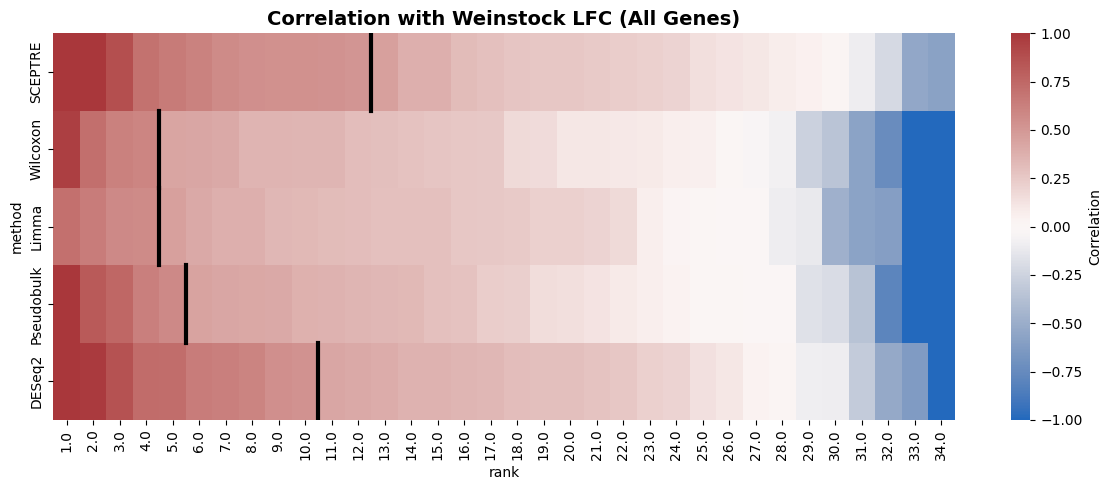

In [8]:
# Create heatmap for all genes
corr_long["rank"] = corr_long.groupby("method")["correlation"].rank(ascending=False, method="first")
wide = corr_long.pivot_table(index="method", columns="rank", values="correlation",aggfunc="mean")
wide = wide.reindex(method_order)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(wide, cmap = "vlag", center = 0, ax=ax, cbar_kws={'label': 'Correlation'})

# Add vertical bar at 0.5 cutoff for each method
for i, method in enumerate(method_order):
    method_row = wide.loc[method]
    cutoff_position = None
    for col_num in range(len(method_row)):
        correlation_value = method_row.iloc[col_num]
        if not pd.isna(correlation_value) and correlation_value < 0.5:
            cutoff_position = col_num
            break
    
    if cutoff_position is not None:
        ymin = (len(method_order) - i - 1) / len(method_order)
        ymax = (len(method_order) - i) / len(method_order)
        ax.axvline(x=cutoff_position, ymin=ymin, ymax=ymax, 
                  color='black', linewidth=3, linestyle='-')

plt.title('Correlation with Weinstock LFC (All Genes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/g/stegle/schrod/code/TCell/plots/final/Weinstock_Heatmap_all_genes.pdf')
plt.show()
